<a href="https://colab.research.google.com/github/gunaanand08/Ioe/blob/main/experiment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 SMART GREENHOUSE LIVE MONITORING 
Plants Processed : 11/25
Elapsed Time     : 20 seconds



,Plant,Humidity (%),Soil Moisture (%),Light Intensity (Lux),Status
0,PL01,69.2,76,744,NORMAL
1,PL02,80.1,57,290,ATTENTION
2,PL03,59.4,39,900,NORMAL
3,PL04,69.5,36,381,NORMAL
4,PL05,50.6,44,986,NORMAL
5,PL06,52.5,80,568,NORMAL
6,PL07,83.5,31,207,ATTENTION
7,PL08,72.0,69,968,NORMAL
8,PL09,47.4,53,531,ATTENTION
9,PL10,57.8,33,845,NORMAL



Normal Plants    : 8
Attention Plants : 3

⚠️ GREENHOUSE ALERT ⚠️


,Plant,Humidity (%),Soil Moisture (%),Light Intensity (Lux),Status
1,PL02,80.1,57,290,ATTENTION
6,PL07,83.5,31,207,ATTENTION
8,PL09,47.4,53,531,ATTENTION


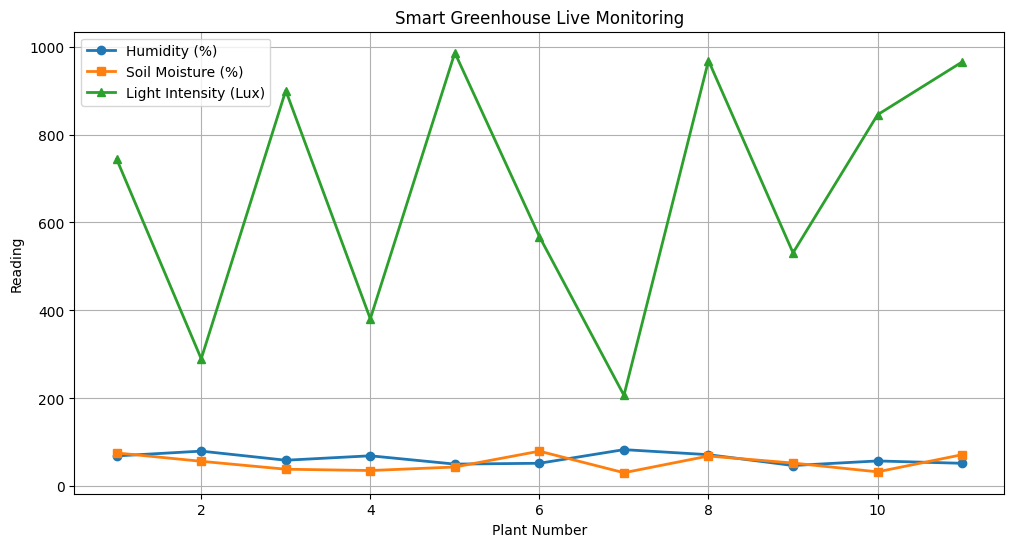

KeyboardInterrupt: 

In [ ]:
# ==========================================================
# SMART GREENHOUSE LIVE MONITORING SYSTEM
# ==========================================================

import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# ==========================================================
# SETTINGS
# ==========================================================

TOTAL_PLANTS = 25          # Total number of plants
UPDATE_INTERVAL = 2        # Seconds between plants

# ==========================================================
# STORAGE LISTS
# ==========================================================

plant_ids = []
humidity_values = []
soil_moisture_values = []
light_values = []
status_list = []
time_axis = []

# ==========================================================
# FUNCTION TO GENERATE PLANT DATA
# ==========================================================

def generate_plant():

    humidity = round(random.uniform(45, 85), 1)
    soil_moisture = random.randint(20, 80)
    light_intensity = random.randint(200, 1000)

    if humidity < 50 or soil_moisture < 30 or light_intensity < 300:
        status = "ATTENTION"
    else:
        status = "NORMAL"

    return humidity, soil_moisture, light_intensity, status

# ==========================================================
# LIVE GRAPH FUNCTION
# ==========================================================

def live_graph():

    plt.figure(figsize=(12,6))

    plt.plot(time_axis, humidity_values,
             marker='o', linewidth=2,
             label="Humidity (%)")

    plt.plot(time_axis, soil_moisture_values,
             marker='s', linewidth=2,
             label="Soil Moisture (%)")

    plt.plot(time_axis, light_values,
             marker='^', linewidth=2,
             label="Light Intensity (Lux)")

    plt.title("Smart Greenhouse Live Monitoring")
    plt.xlabel("Plant Number")
    plt.ylabel("Reading")
    plt.grid(True)
    plt.legend()

    plt.show()

# ==========================================================
# LIVE MONITORING LOOP
# ==========================================================

for plant in range(1, TOTAL_PLANTS + 1):

    humidity, soil_moisture, light_intensity, status = generate_plant()

    plant_ids.append(f"PL{plant:02d}")
    humidity_values.append(humidity)
    soil_moisture_values.append(soil_moisture)
    light_values.append(light_intensity)
    status_list.append(status)
    time_axis.append(plant)

    df = pd.DataFrame({
        "Plant": plant_ids,
        "Humidity (%)": humidity_values,
        "Soil Moisture (%)": soil_moisture_values,
        "Light Intensity (Lux)": light_values,
        "Status": status_list
    })

    clear_output(wait=True)

    print("=" * 70)
    print(" SMART GREENHOUSE LIVE MONITORING ")
    print("=" * 70)

    print(f"Plants Processed : {plant}/{TOTAL_PLANTS}")
    print(f"Elapsed Time     : {(plant-1)*UPDATE_INTERVAL} seconds\n")

    display(df)

    attention = df[df["Status"] == "ATTENTION"]

    print("\nNormal Plants    :", len(df) - len(attention))
    print("Attention Plants :", len(attention))

    if len(attention) > 0:
        print("\n⚠️ GREENHOUSE ALERT ⚠️")
        display(attention)

    live_graph()

    if plant != TOTAL_PLANTS:
        time.sleep(UPDATE_INTERVAL)

# ==========================================================
# FINAL REPORT
# ==========================================================

print("\n")
print("=" * 70)
print("MONITORING COMPLETED SUCCESSFULLY")
print("=" * 70)

final_df = pd.DataFrame({
    "Plant": plant_ids,
    "Humidity (%)": humidity_values,
    "Soil Moisture (%)": soil_moisture_values,
    "Light Intensity (Lux)": light_values,
    "Status": status_list
})

display(final_df)

final_df.to_csv("Smart_Greenhouse_Report.csv", index=False)

print("\nCSV file saved as Smart_Greenhouse_Report.csv")